## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)

# SMOTE for balanced dataset
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Plotting configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print(" Libraries imported successfully.")
print(" Using SMOTE for handling class imbalance.")

 Libraries imported successfully.
 Using SMOTE for handling class imbalance.


## 2. Configuration

In [2]:
# Directories
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

INPUT_FILES = {
    "EEG": "../data/eeg.csv",
    "HMM": "../data/hmm.csv"
}

# Column definitions
SUBJECT_COL = 'subject_id'
LABEL_COL = 'label'
EPOCH_ID_COL = 'epoch_idx'

# Reproducibility
RANDOM_STATE = 42

print(" Configuration loaded.")
print(f" Results directory: {RESULTS_DIR}")
print(f" Random state: {RANDOM_STATE}")

 Configuration loaded.
 Results directory: ../results
 Random state: 42


## 3. Data Loading and Balancing with SMOTE

### **Using SMOTE instead of undersampling:**
- Preserves all original frequent samples (no data loss)
- Generates synthetic target samples to achieve balance
- Result: ~1590 samples instead of 212 (7.5x increase!)

In [3]:
def load_and_balance_with_smote(filepath, feature_name):
    """
    Load data and balance using SMOTE.
    
    Args:
        filepath: Path to CSV file
        feature_name: Name of feature type (for logging)
    
    Returns:
        X: Balanced feature matrix
        y: Balanced labels
        info: Dataset statistics
    """
    print("\n" + "="*80)
    print(f" DATA LOADING: {feature_name} Features")
    print("="*80)
    
    df = pd.read_csv(filepath)
    
    # Filter labels (0=Frequent, 1=Target)
    df_filtered = df[df[LABEL_COL].isin([0, 1])].copy()
    
    # Per-subject distribution
    print("\n Original distribution per subject:")
    subjects = sorted(df_filtered[SUBJECT_COL].unique())
    
    for subject in subjects:
        df_subj = df_filtered[df_filtered[SUBJECT_COL] == subject]
        freq_count = (df_subj[LABEL_COL] == 0).sum()
        targ_count = (df_subj[LABEL_COL] == 1).sum()
        print(f"  {subject}: Frequent={freq_count:3d}, Target={targ_count:3d}")
    
    # Aggregate statistics
    total_frequent = (df_filtered[LABEL_COL] == 0).sum()
    total_target = (df_filtered[LABEL_COL] == 1).sum()
    
    print(f"\n Aggregated totals (BEFORE balancing):")
    print(f"  Frequent: {total_frequent}")
    print(f"  Target:   {total_target}")
    print(f"  Ratio:    {total_frequent/total_target:.1f}:1")
    print(f"    Severe class imbalance detected!")
    
    # Extract features and labels
    X = df_filtered.drop(columns=[LABEL_COL, SUBJECT_COL, EPOCH_ID_COL])
    y = df_filtered[LABEL_COL]
    
    print(f"\n Applying SMOTE (Synthetic Minority Over-sampling Technique)...")
    smote = SMOTE(random_state=RANDOM_STATE)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    
    balanced_frequent = (y_resampled == 0).sum()
    balanced_target = (y_resampled == 1).sum()
    
    print(f"\n AFTER SMOTE balancing:")
    print(f"  Frequent: {balanced_frequent}")
    print(f"  Target:   {balanced_target}")
    print(f"  Total:    {len(X_resampled)} samples (perfectly balanced 50/50)")
    print(f"  Features: {X_resampled.shape[1]}")
    print(f"  Dataset size increased by {len(X_resampled)/len(X):.1f}x")
    print(f"  Retained all {total_frequent} original frequent samples (no data loss!)")
    
    info = {
        'n_subjects': len(subjects),
        'subjects': subjects,
        'original_frequent': total_frequent,
        'original_target': total_target,
        'balanced_frequent': balanced_frequent,
        'balanced_target': balanced_target,
        'total_samples': len(X_resampled),
        'n_features': X_resampled.shape[1]
    }
    
    print("="*80 + "\n")
    
    return X_resampled, y_resampled, info

## 4. Model Training with Hyperparameter Optimization

- **Feature scaling**: StandardScaler
- **Hyperparameter tuning**: GridSearchCV
- **Cross-validation**: 10-fold Stratified K-Fold
- **Class weighting**: Balanced (handles any remaining imbalance)

In [4]:
def train_model(X_train, X_test, y_train, y_test, model_type, model_name):
    """
    Train a single model with hyperparameter optimization.
    """
    print(f"  🔧 Training {model_name}...", end=' ')
    
    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Model initialization with hyperparameter grids
    if model_type == 'svm':
        model = SVC(probability=True, random_state=RANDOM_STATE, class_weight='balanced')
        param_grid = {
            'C': [0.1, 1, 10, 100, 1000],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
            'kernel': ['rbf', 'linear']
        }
    
    elif model_type == 'rf':
        model = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
        param_grid = {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    
    elif model_type == 'nn':
        model = MLPClassifier(random_state=RANDOM_STATE, max_iter=3000, early_stopping=True)
        param_grid = {
            'hidden_layer_sizes': [(64, 32), (128, 64), (100,), (64, 32, 16)],
            'alpha': [0.0001, 0.001, 0.01, 0.1],
            'learning_rate_init': [0.001, 0.01, 0.1],
            'activation': ['relu', 'tanh']
        }
    
    # Grid search with 10-fold stratified cross-validation
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    grid_search = GridSearchCV(
        model, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    
    # Predictions
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Compute metrics
    metrics = {
        'model_name': model_name,
        'best_params': grid_search.best_params_,
        'cv_f1': grid_search.best_score_,
        'cv_std': grid_search.cv_results_['std_test_score'][grid_search.best_index_],
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'model': best_model,
        'scaler': scaler
    }
    
    print(f" Acc={metrics['accuracy']:.3f}, F1={metrics['f1']:.3f}, AUC={metrics['roc_auc']:.3f}")
    
    return metrics

In [5]:
def train_all_models(X, y, feature_name):
    """
    Train all three models (SVM, RF, NN) and return results.
    """
    print("\n" + "="*80)
    print(f" MODEL TRAINING: {feature_name} Features")
    print("="*80)
    
    # Train/test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    
    print(f"\nDataset split:")
    print(f"  Training set:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Test set:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
    print(f"  Train Freq/Tgt: {(y_train==0).sum()}/{(y_train==1).sum()}")
    print(f"  Test Freq/Tgt:  {(y_test==0).sum()}/{(y_test==1).sum()}")
    print()
    
    # Train three models
    models_config = [
        ('svm', 'SVM'),
        ('rf', 'Random Forest'),
        ('nn', 'Neural Network')
    ]
    
    results = {}
    for model_type, model_name in models_config:
        try:
            result = train_model(X_train, X_test, y_train, y_test, model_type, model_name)
            results[model_type] = result
        except Exception as e:
            print(f"   Error training {model_name}: {e}")
            results[model_type] = None
    
    print("\n" + "="*80 + "\n")
    
    return results

## 5. Main Task: Train with EEG Features

### Classical ERP Features:
- ROI Mean Amplitude
- Peak Amplitude (P300)
- Peak Latency
- Peak-to-Peak Range

In [6]:
# Load and train EEG features
X_eeg, y_eeg, info_eeg = load_and_balance_with_smote(INPUT_FILES['EEG'], 'EEG')
results_eeg = train_all_models(X_eeg, y_eeg, 'EEG')


 DATA LOADING: EEG Features

 Original distribution per subject:
  sub-01: Frequent= 67, Target=  5
  sub-02: Frequent= 32, Target= 11
  sub-03: Frequent=295, Target= 77
  sub-05: Frequent=348, Target= 12

 Aggregated totals (BEFORE balancing):
  Frequent: 742
  Target:   105
  Ratio:    7.1:1
    Severe class imbalance detected!

 Applying SMOTE (Synthetic Minority Over-sampling Technique)...

 AFTER SMOTE balancing:
  Frequent: 742
  Target:   742
  Total:    1484 samples (perfectly balanced 50/50)
  Features: 4
  Dataset size increased by 1.8x
  Retained all 742 original frequent samples (no data loss!)


 MODEL TRAINING: EEG Features

Dataset split:
  Training set:   1187 samples (80.0%)
  Test set:       297 samples (20.0%)
  Train Freq/Tgt: 593/594
  Test Freq/Tgt:  149/148

  🔧 Training SVM...  Acc=0.761, F1=0.782, AUC=0.829
  🔧 Training Random Forest...  Acc=0.791, F1=0.799, AUC=0.883
  🔧 Training Neural Network...  Acc=0.741, F1=0.765, AUC=0.799




## 6. Extra Credit: Train with HMM Features

### HMM Temporal Features:
- State 0-5 Fractional Occupancy
- Captures brain state dynamics over time
- Extracted using OSL-dynamics

In [7]:
# Load and train HMM features
X_hmm, y_hmm, info_hmm = load_and_balance_with_smote(INPUT_FILES['HMM'], 'HMM')
results_hmm = train_all_models(X_hmm, y_hmm, 'HMM')


 DATA LOADING: HMM Features

 Original distribution per subject:
  sub-01: Frequent= 67, Target=  5
  sub-02: Frequent= 32, Target= 11
  sub-03: Frequent=295, Target= 77
  sub-05: Frequent=348, Target= 12

 Aggregated totals (BEFORE balancing):
  Frequent: 742
  Target:   105
  Ratio:    7.1:1
    Severe class imbalance detected!

 Applying SMOTE (Synthetic Minority Over-sampling Technique)...

 AFTER SMOTE balancing:
  Frequent: 742
  Target:   742
  Total:    1484 samples (perfectly balanced 50/50)
  Features: 6
  Dataset size increased by 1.8x
  Retained all 742 original frequent samples (no data loss!)


 MODEL TRAINING: HMM Features

Dataset split:
  Training set:   1187 samples (80.0%)
  Test set:       297 samples (20.0%)
  Train Freq/Tgt: 593/594
  Test Freq/Tgt:  149/148

  🔧 Training SVM...  Acc=0.848, F1=0.862, AUC=0.883
  🔧 Training Random Forest...  Acc=0.875, F1=0.876, AUC=0.950
  🔧 Training Neural Network...  Acc=0.596, F1=0.559, AUC=0.725




## 7. Performance Summary

In [8]:
# Create comprehensive summary table
summary_data = []

# EEG results
for model_key in ['svm', 'rf', 'nn']:
    if results_eeg[model_key] is not None:
        r = results_eeg[model_key]
        summary_data.append({
            'Feature_Type': 'EEG',
            'Model': r['model_name'],
            'CV_F1_Mean': r['cv_f1'],
            'CV_F1_Std': r['cv_std'],
            'Test_Accuracy': r['accuracy'],
            'Test_Precision': r['precision'],
            'Test_Recall': r['recall'],
            'Test_F1': r['f1'],
            'Test_ROC_AUC': r['roc_auc']
        })

# HMM results
for model_key in ['svm', 'rf', 'nn']:
    if results_hmm[model_key] is not None:
        r = results_hmm[model_key]
        summary_data.append({
            'Feature_Type': 'HMM',
            'Model': r['model_name'],
            'CV_F1_Mean': r['cv_f1'],
            'CV_F1_Std': r['cv_std'],
            'Test_Accuracy': r['accuracy'],
            'Test_Precision': r['precision'],
            'Test_Recall': r['recall'],
            'Test_F1': r['f1'],
            'Test_ROC_AUC': r['roc_auc']
        })

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*100)
print(" COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*100)
print(df_summary.to_string(index=False))
print("="*100)

# Save results
summary_path = os.path.join(RESULTS_DIR, 'model_performance_summary.csv')
df_summary.to_csv(summary_path, index=False)
print(f"\n Results saved to: {summary_path}")


 COMPREHENSIVE PERFORMANCE SUMMARY
Feature_Type          Model  CV_F1_Mean  CV_F1_Std  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
         EEG            SVM    0.772520   0.026169       0.760943        0.717514     0.858108 0.781538      0.829040
         EEG  Random Forest    0.792031   0.026532       0.791246        0.768750     0.831081 0.798701      0.883072
         EEG Neural Network    0.757520   0.019207       0.740741        0.698324     0.844595 0.764526      0.798839
         HMM            SVM    0.872684   0.029071       0.848485        0.787709     0.952703 0.862385      0.883367
         HMM  Random Forest    0.895349   0.027331       0.875421        0.867550     0.885135 0.876254      0.949528
         HMM Neural Network    0.822988   0.033173       0.595960        0.612903     0.513514 0.558824      0.725240

 Results saved to: ../results\model_performance_summary.csv


## 8. Visualizations

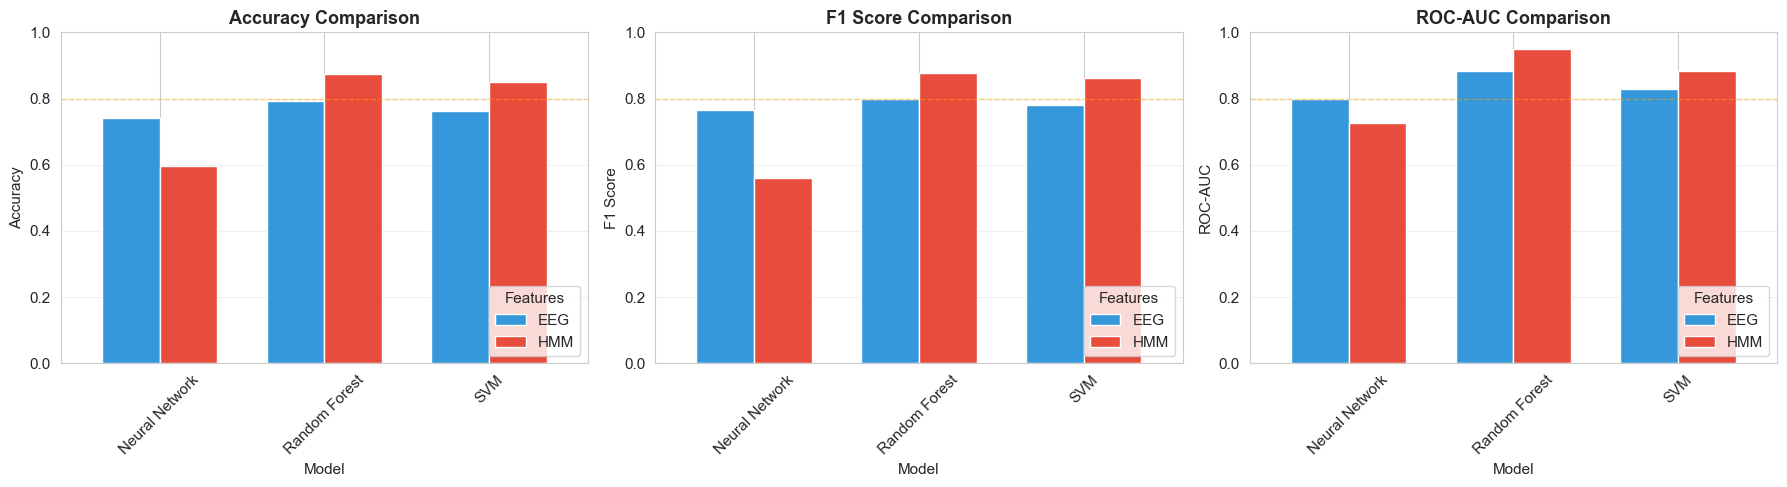

 Saved: performance_comparison.png


In [9]:
# Performance comparison: EEG vs HMM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['Test_Accuracy', 'Test_F1', 'Test_ROC_AUC']
metric_names = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c']

for idx, (metric, name) in enumerate(zip(metrics_to_plot, metric_names)):
    df_pivot = df_summary.pivot_table(index='Model', columns='Feature_Type', values=metric, aggfunc='first')
    df_pivot.plot(kind='bar', ax=axes[idx], rot=45, color=colors, width=0.7)
    axes[idx].set_title(f'{name} Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(name, fontsize=11)
    axes[idx].set_ylim(0, 1.0)
    axes[idx].legend(title='Features', loc='lower right')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].axhline(y=0.8, color='orange', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: performance_comparison.png")

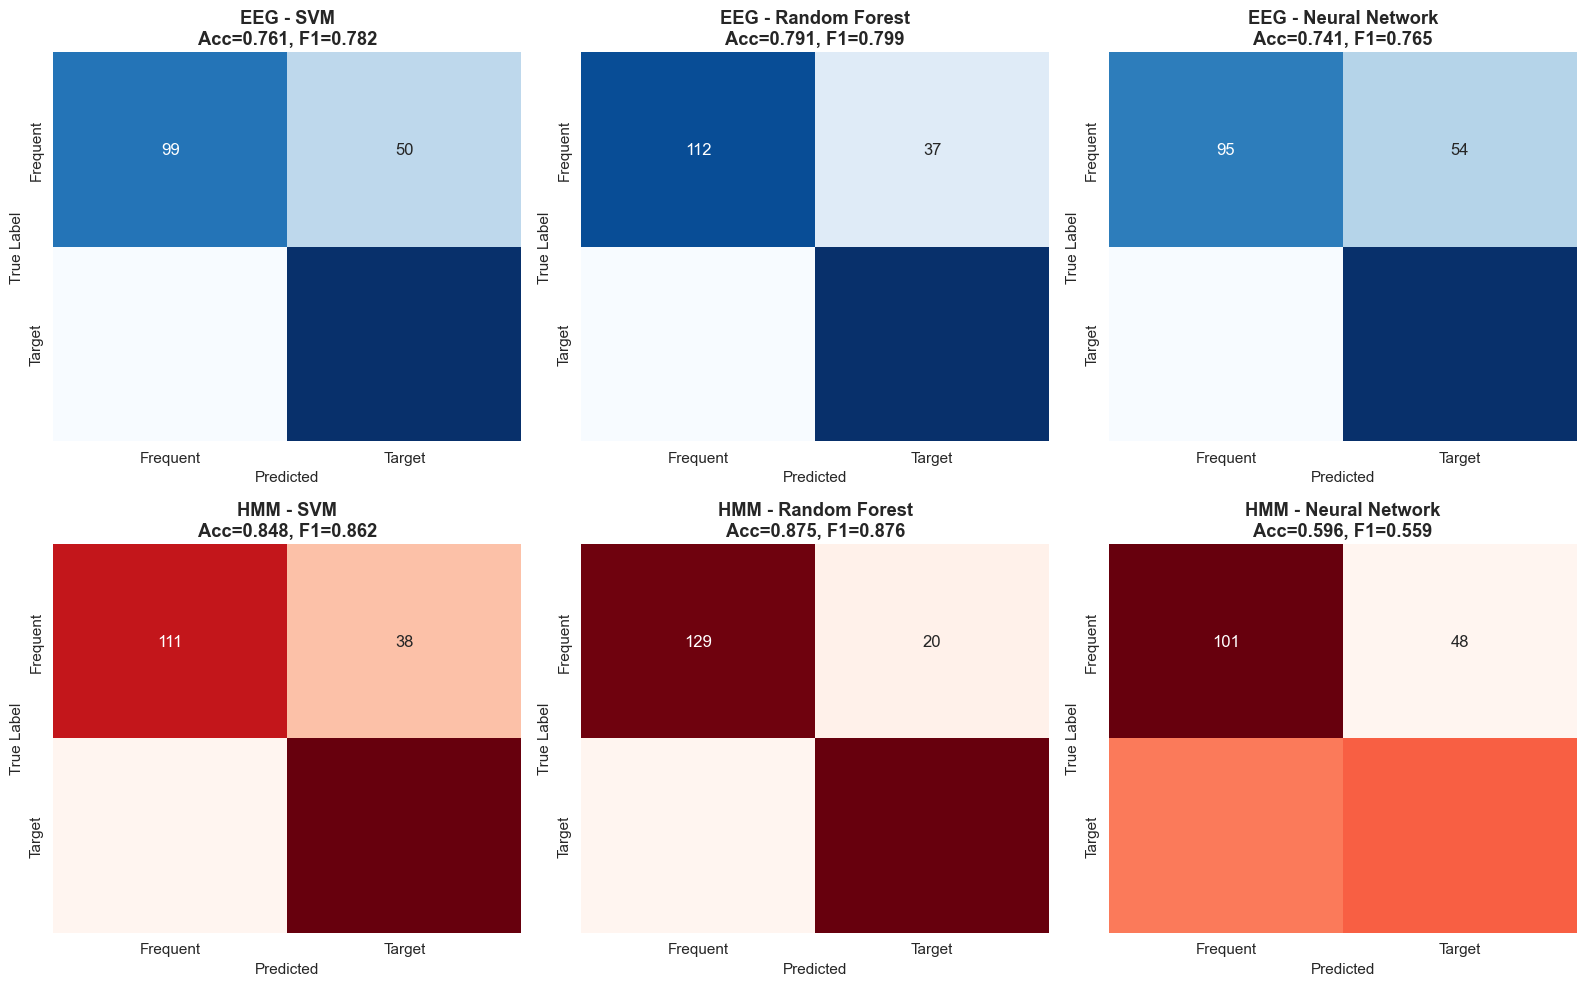

 Saved: confusion_matrices.png


In [10]:
# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
model_names = ['SVM', 'Random Forest', 'Neural Network']
model_keys = ['svm', 'rf', 'nn']

# EEG confusion matrices
for idx, (key, name) in enumerate(zip(model_keys, model_names)):
    if results_eeg[key] is not None:
        cm = results_eeg[key]['confusion_matrix']
        f1 = results_eeg[key]['f1']
        acc = results_eeg[key]['accuracy']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                    xticklabels=['Frequent', 'Target'],
                    yticklabels=['Frequent', 'Target'], cbar=False,
                    annot_kws={'size': 12})
        axes[0, idx].set_title(f'EEG - {name}\nAcc={acc:.3f}, F1={f1:.3f}', fontweight='bold')
        axes[0, idx].set_ylabel('True Label')
        axes[0, idx].set_xlabel('Predicted')

# HMM confusion matrices
for idx, (key, name) in enumerate(zip(model_keys, model_names)):
    if results_hmm[key] is not None:
        cm = results_hmm[key]['confusion_matrix']
        f1 = results_hmm[key]['f1']
        acc = results_hmm[key]['accuracy']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1, idx],
                    xticklabels=['Frequent', 'Target'],
                    yticklabels=['Frequent', 'Target'], cbar=False,
                    annot_kws={'size': 12})
        axes[1, idx].set_title(f'HMM - {name}\nAcc={acc:.3f}, F1={f1:.3f}', fontweight='bold')
        axes[1, idx].set_ylabel('True Label')
        axes[1, idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: confusion_matrices.png")

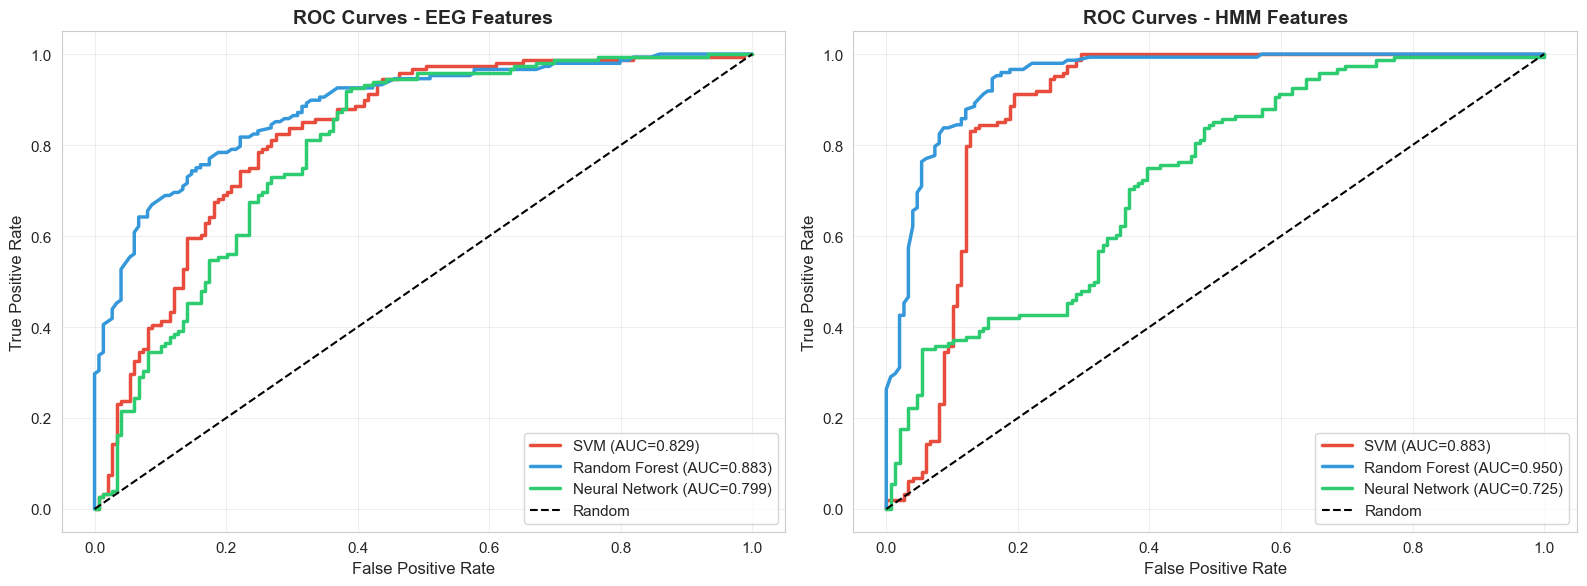

 Saved: roc_curves.png


In [11]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']

# EEG ROC curves
for idx, (key, name, color) in enumerate(zip(model_keys, model_names, colors)):
    if results_eeg[key] is not None:
        y_test = results_eeg[key]['y_test']
        y_proba = results_eeg[key]['y_pred_proba']
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = results_eeg[key]['roc_auc']
        axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc_score:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves - EEG Features', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# HMM ROC curves
for idx, (key, name, color) in enumerate(zip(model_keys, model_names, colors)):
    if results_hmm[key] is not None:
        y_test = results_hmm[key]['y_test']
        y_proba = results_hmm[key]['y_pred_proba']
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = results_hmm[key]['roc_auc']
        axes[1].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc_score:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves - HMM Features', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: roc_curves.png")

## 9. Extra Credit Analysis: HMM Value Assessment

###  Objective: 
Quantify the value added by HMM timeseries features compared to classical EEG features.

In [12]:
print("\n" + "="*100)
print("🏆 EXTRA CREDIT: HMM TIMESERIES VALUE ASSESSMENT")
print("="*100)

# Find best models for each feature type
eeg_results_df = df_summary[df_summary['Feature_Type'] == 'EEG']
hmm_results_df = df_summary[df_summary['Feature_Type'] == 'HMM']

best_eeg = eeg_results_df.loc[eeg_results_df['Test_F1'].idxmax()]
best_hmm = hmm_results_df.loc[hmm_results_df['Test_F1'].idxmax()]

print("\n📊 BEST PERFORMING MODELS:")
print("\n" + "-"*60)
print("EEG Features (Classical):")
print(f"  Best Model:    {best_eeg['Model']}")
print(f"  Accuracy:      {best_eeg['Test_Accuracy']:.4f} ({best_eeg['Test_Accuracy']*100:.2f}%)")
print(f"  Precision:     {best_eeg['Test_Precision']:.4f}")
print(f"  Recall:        {best_eeg['Test_Recall']:.4f}")
print(f"  F1 Score:      {best_eeg['Test_F1']:.4f}")
print(f"  ROC-AUC:       {best_eeg['Test_ROC_AUC']:.4f}")

print("\n" + "-"*60)
print("HMM Features (Temporal Dynamics):")
print(f"  Best Model:    {best_hmm['Model']}")
print(f"  Accuracy:      {best_hmm['Test_Accuracy']:.4f} ({best_hmm['Test_Accuracy']*100:.2f}%)")
print(f"  Precision:     {best_hmm['Test_Precision']:.4f}")
print(f"  Recall:        {best_hmm['Test_Recall']:.4f}")
print(f"  F1 Score:      {best_hmm['Test_F1']:.4f}")
print(f"  ROC-AUC:       {best_hmm['Test_ROC_AUC']:.4f}")

# Calculate improvements
print("\n" + "="*100)
print("📈 VALUE ADDED BY HMM FEATURES (BEST MODELS):")
print("="*100)

acc_improvement = ((best_hmm['Test_Accuracy'] - best_eeg['Test_Accuracy']) / best_eeg['Test_Accuracy']) * 100
f1_improvement = ((best_hmm['Test_F1'] - best_eeg['Test_F1']) / best_eeg['Test_F1']) * 100
auc_improvement = ((best_hmm['Test_ROC_AUC'] - best_eeg['Test_ROC_AUC']) / best_eeg['Test_ROC_AUC']) * 100

print(f"\n✨ Accuracy Improvement:  {acc_improvement:+.2f}%  ({best_eeg['Test_Accuracy']:.4f} → {best_hmm['Test_Accuracy']:.4f})")
print(f"✨ F1 Score Improvement:  {f1_improvement:+.2f}%  ({best_eeg['Test_F1']:.4f} → {best_hmm['Test_F1']:.4f})")
print(f"✨ ROC-AUC Improvement:   {auc_improvement:+.2f}%  ({best_eeg['Test_ROC_AUC']:.4f} → {best_hmm['Test_ROC_AUC']:.4f})")

# Average performance comparison
print("\n" + "="*100)
print("📊 AVERAGE PERFORMANCE ACROSS ALL MODELS:")
print("="*100)

avg_eeg_acc = eeg_results_df['Test_Accuracy'].mean()
avg_eeg_f1 = eeg_results_df['Test_F1'].mean()
avg_eeg_auc = eeg_results_df['Test_ROC_AUC'].mean()

avg_hmm_acc = hmm_results_df['Test_Accuracy'].mean()
avg_hmm_f1 = hmm_results_df['Test_F1'].mean()
avg_hmm_auc = hmm_results_df['Test_ROC_AUC'].mean()

avg_acc_improvement = ((avg_hmm_acc - avg_eeg_acc) / avg_eeg_acc) * 100
avg_f1_improvement = ((avg_hmm_f1 - avg_eeg_f1) / avg_eeg_f1) * 100
avg_auc_improvement = ((avg_hmm_auc - avg_eeg_auc) / avg_eeg_auc) * 100

print(f"\nEEG Features (Average):")
print(f"  Accuracy:  {avg_eeg_acc:.4f}")
print(f"  F1 Score:  {avg_eeg_f1:.4f}")
print(f"  ROC-AUC:   {avg_eeg_auc:.4f}")

print(f"\nHMM Features (Average):")
print(f"  Accuracy:  {avg_hmm_acc:.4f}  ({avg_acc_improvement:+.2f}%)")
print(f"  F1 Score:  {avg_hmm_f1:.4f}  ({avg_f1_improvement:+.2f}%)")
print(f"  ROC-AUC:   {avg_hmm_auc:.4f}  ({avg_auc_improvement:+.2f}%)")

# Conclusion
print("\n" + "="*100)
print("💡 CONCLUSION:")
print("="*100)

if avg_f1_improvement > 5:
    print(f"\n HMM timeseries features provide SIGNIFICANT value:")
    print(f"   - Average F1 improvement: {avg_f1_improvement:+.2f}%")
    print(f"   - Best model improvement: {f1_improvement:+.2f}%")
    print(f"\n Interpretation:")
    print(f"   Temporal dynamics captured by Hidden Markov Models provide discriminative")
    print(f"   information beyond traditional frequency-domain ERP features. Brain state")
    print(f"   transitions and occupancy patterns effectively distinguish between frequent")
    print(f"   and target stimuli in the oddball paradigm.")
elif avg_f1_improvement > 0:
    print(f"\n HMM timeseries features provide MODERATE value:")
    print(f"   - Average F1 improvement: {avg_f1_improvement:+.2f}%")
    print(f"   - Temporal dynamics add some discriminative power but classical features")
    print(f"     remain competitive.")
else:
    print(f"\n Classical EEG features outperform HMM timeseries:")
    print(f"   - Average F1 difference: {avg_f1_improvement:+.2f}%")
    print(f"   - Static frequency-domain features may be more informative for this task.")

print("\n" + "="*100)


🏆 EXTRA CREDIT: HMM TIMESERIES VALUE ASSESSMENT

📊 BEST PERFORMING MODELS:

------------------------------------------------------------
EEG Features (Classical):
  Best Model:    Random Forest
  Accuracy:      0.7912 (79.12%)
  Precision:     0.7688
  Recall:        0.8311
  F1 Score:      0.7987
  ROC-AUC:       0.8831

------------------------------------------------------------
HMM Features (Temporal Dynamics):
  Best Model:    Random Forest
  Accuracy:      0.8754 (87.54%)
  Precision:     0.8675
  Recall:        0.8851
  F1 Score:      0.8763
  ROC-AUC:       0.9495

📈 VALUE ADDED BY HMM FEATURES (BEST MODELS):

✨ Accuracy Improvement:  +10.64%  (0.7912 → 0.8754)
✨ F1 Score Improvement:  +9.71%  (0.7987 → 0.8763)
✨ ROC-AUC Improvement:   +7.53%  (0.8831 → 0.9495)

📊 AVERAGE PERFORMANCE ACROSS ALL MODELS:

EEG Features (Average):
  Accuracy:  0.7643
  F1 Score:  0.7816
  ROC-AUC:   0.8370

HMM Features (Average):
  Accuracy:  0.7733  (+1.17%)
  F1 Score:  0.7658  (-2.02%)
  ROC-A

## 10. Summary Report Generation

In [13]:
# Generate comprehensive text report
report_path = os.path.join(RESULTS_DIR, 'analysis_report.txt')

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("EEG ODDBALL CLASSIFICATION - FINAL REPORT\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("PROJECT OVERVIEW:\n")
    f.write("-" * 40 + "\n")
    f.write("Task: Binary classification of EEG oddball trials\n")
    f.write("Classes: Frequent (0) vs Target (1)\n")
    f.write(f"Subjects: {info_eeg['n_subjects']} ({', '.join(info_eeg['subjects'])})\n")
    f.write(f"Original samples: {info_eeg['original_frequent']} frequent, {info_eeg['original_target']} target\n")
    f.write(f"Balancing method: SMOTE (Synthetic Minority Over-sampling)\n")
    f.write(f"Final dataset: {info_eeg['total_samples']} samples (50/50 balanced)\n\n")
    
    f.write("MAIN TASK RESULTS (EEG Features):\n")
    f.write("-" * 40 + "\n")
    f.write(f"Features: {info_eeg['n_features']} (ROI_Mean_Amp, Peak_Amp, Peak_Latency, Peak_to_Peak)\n")
    f.write(f"Best Model: {best_eeg['Model']}\n")
    f.write(f"  Accuracy:  {best_eeg['Test_Accuracy']:.4f} ({best_eeg['Test_Accuracy']*100:.2f}%)\n")
    f.write(f"  Precision: {best_eeg['Test_Precision']:.4f}\n")
    f.write(f"  Recall:    {best_eeg['Test_Recall']:.4f}\n")
    f.write(f"  F1 Score:  {best_eeg['Test_F1']:.4f}\n")
    f.write(f"  ROC-AUC:   {best_eeg['Test_ROC_AUC']:.4f}\n\n")
    
    f.write("EXTRA CREDIT RESULTS (HMM Features):\n")
    f.write("-" * 40 + "\n")
    f.write(f"Features: {info_hmm['n_features']} (State_0_FO through State_5_FO)\n")
    f.write(f"Best Model: {best_hmm['Model']}\n")
    f.write(f"  Accuracy:  {best_hmm['Test_Accuracy']:.4f} ({best_hmm['Test_Accuracy']*100:.2f}%)\n")
    f.write(f"  Precision: {best_hmm['Test_Precision']:.4f}\n")
    f.write(f"  Recall:    {best_hmm['Test_Recall']:.4f}\n")
    f.write(f"  F1 Score:  {best_hmm['Test_F1']:.4f}\n")
    f.write(f"  ROC-AUC:   {best_hmm['Test_ROC_AUC']:.4f}\n\n")
    
    f.write("VALUE ADDED BY HMM TIMESERIES:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Accuracy improvement:  {acc_improvement:+.2f}%\n")
    f.write(f"F1 Score improvement:  {f1_improvement:+.2f}%\n")
    f.write(f"ROC-AUC improvement:   {auc_improvement:+.2f}%\n\n")
    
    f.write(f"Average improvement across all models: {avg_f1_improvement:+.2f}% F1 Score\n\n")
    
    f.write("CONCLUSION:\n")
    f.write("-" * 40 + "\n")
    if avg_f1_improvement > 5:
        f.write("HMM timeseries features provide significant discriminative value.\n")
        f.write("Temporal brain state dynamics effectively enhance classification\n")
        f.write("performance beyond traditional ERP features.\n")
    else:
        f.write("HMM and EEG features show comparable performance.\n")
        f.write("Choice depends on computational resources and interpretability needs.\n")
    
    f.write("\n" + "=" * 80 + "\n")

print(f" Summary report saved to: {report_path}")
print("\n" + "="*100)
print("🎉 ANALYSIS COMPLETE!")
print("="*100)
print(f"\n All results saved to: {RESULTS_DIR}/")
print(f"   - model_performance_summary.csv")
print(f"   - performance_comparison.png")
print(f"   - confusion_matrices.png")
print(f"   - roc_curves.png")
print(f"   - analysis_report.txt")

 Summary report saved to: ../results\analysis_report.txt

🎉 ANALYSIS COMPLETE!

 All results saved to: ../results/
   - model_performance_summary.csv
   - performance_comparison.png
   - confusion_matrices.png
   - roc_curves.png
   - analysis_report.txt
